## Screenings EDA
**Dataset:** `Screenings.csv`, joined against `Measurements.csv`,
`Practitioners.csv`, `Programmes.csv`, and `Employees.csv`.

**Grain (verified in Section 1):** one row in `Screenings` = one screening
event, a single service/station administered to a single participation,
during a screening encounter/visit.

This EDA follows the same structure as the previous ones.
1. Load & shape
2. Grain integrity
3. Structural vs. defect null classification
4. **Confirmed relationships**; joins against Measurements, Practitioners, Programmes and Employees
5. Categorical distributions
6. Cross-field chronological validation
7. Sequence anomaly detection (and whether it propagates into Measurements)
8. Duplicate screening detection
9. Cross-check against prior EDA flags (`PAR-017`)
10. Summary of findings, remaining gaps, and open questions

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import missingno as msno

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

scr = pd.read_csv(r'C:\Users\Gene\OneDrive\Desktop\VS-Code Python\Span\CSV Files\Screenings.csv')
meas = pd.read_csv(r'C:\Users\Gene\OneDrive\Desktop\VS-Code Python\Span\CSV Files\Measurements.csv')
prac = pd.read_csv(r'C:\Users\Gene\OneDrive\Desktop\VS-Code Python\Span\CSV Files\Practitioners.csv')
prog = pd.read_csv(r'C:\Users\Gene\OneDrive\Desktop\VS-Code Python\Span\CSV Files\Programmes.csv')
emp = pd.read_csv(r'C:\Users\Gene\OneDrive\Desktop\VS-Code Python\Span\CSV Files\Employees.csv')

print(f"Screenings:    {scr.shape}")
print(f"Measurements:  {meas.shape}")
print(f"Practitioners: {prac.shape}")
print(f"Programmes:    {prog.shape}")
print(f"Employees:     {emp.shape}")

Screenings:    (144, 8)
Measurements:  (264, 8)
Practitioners: (3, 8)
Programmes:    (1, 11)
Employees:     (28, 10)


In [9]:
scr.head(10)

,screening_id,participation_id,programme_service_id,practitioner_id,screened_at,status,notes,created_at
0,SCR-0001,PAR-001,PS-001,PRA-002,2026-06-18T07:09:00Z,completed,NaN,2026-06-18T06:30:00Z
1,SCR-0002,PAR-001,PS-002,PRA-002,2026-06-18T07:13:00Z,completed,NaN,2026-06-18T06:30:00Z
2,SCR-0003,PAR-001,PS-003,PRA-002,2026-06-18T07:17:00Z,completed,NaN,2026-06-18T06:30:00Z
3,SCR-0004,PAR-001,PS-004,PRA-002,2026-06-18T07:21:00Z,completed,NaN,2026-06-18T06:30:00Z
4,SCR-0005,PAR-001,PS-005,PRA-002,2026-06-18T07:25:00Z,completed,NaN,2026-06-18T06:30:00Z
5,SCR-0006,PAR-001,PS-006,PRA-003,2026-06-18T07:29:00Z,completed,NaN,2026-06-18T06:30:00Z
6,SCR-0007,PAR-002,PS-001,PRA-001,2026-06-18T07:18:00Z,completed,NaN,2026-06-18T06:30:00Z
7,SCR-0008,PAR-002,PS-002,PRA-001,2026-06-18T07:22:00Z,completed,NaN,2026-06-18T06:30:00Z
8,SCR-0009,PAR-002,PS-003,PRA-001,2026-06-18T07:26:00Z,completed,NaN,2026-06-18T06:30:00Z
9,SCR-0010,PAR-002,PS-004,PRA-001,2026-06-18T07:30:00Z,completed,NaN,2026-06-18T06:30:00Z


## 1. Grain Integrity
Confirming uniqueness and completeness before anything else. This is because every downstream count and rate in this notebook depends  

In [10]:
assert scr['screening_id'].is_unique, "Screening_ID is not unique. Grain assumption is violated."
assert scr['screening_id'].notna().all(), "Screening_ID has null values. Grain assumption is violated."
assert len(scr) == scr['screening_id'].nunique(), "Screening_ID row count does not match unique count. Grain assumption is violated."

print(f"Rows: {len(scr)}")
print(f"Distinct Screening_IDs: {scr['screening_id'].nunique()}")
print(f"PASS: Screening_ID is complete, unique primary key for the Screenings table. Grain assumption is satisfied.")


Rows: 144
Distinct Screening_IDs: 144
PASS: Screening_ID is complete, unique primary key for the Screenings table. Grain assumption is satisfied.


## screening_id sequence integrity
A check to see if the numeric suffix of screening_id has no gaps and duplicates (contiguous). The check also determines whether the ID assignment order matches a deterministic sort order. A perfectly contiguous, order-consistent sequence is a strong
signal this is **generated/synthetic data** produced by a single loop
(e.g. `for participation in participations: for service in services: ...`)
rather than IDs assigned by independent, asynchronous production writes.

In [13]:
nums = scr['screening_id'].str.extract(r'SCR-(\d+)')[0].astype(int)
expected_range = set(range(nums.min(), nums.max() + 1))
gaps = expected_range - set(nums)

assert len(gaps) == 0, f"Screening_ID has gaps in the sequence: {sorted(gaps)}. Grain assumption is violated."
assert nums.is_unique, "Screening_ID numeric sequences are not unique. Grain assumption is violated."

print(f"screening_id numeric range: SCR-{nums.min():04d} to SCR-{nums.max():04d}")
print(f"Gaps in sequence: {sorted(gaps)}")

by_id = scr.sort_values('screening_id')[['participation_id', 'programme_service_id']].reset_index(drop=True)
by_key = scr.sort_values(['participation_id', 'programme_service_id'])[['participation_id', 'programme_service_id']].reset_index(drop=True)
order_matches = by_id.equals(by_key)
print(f"\nscreening_id order matches participation_id and programme_service_id order: {order_matches}")
if order_matches:
    print("Consistent with IDs generated by a single nested loop over "
          "(participation x service) -- a signature of seeded/synthetic data.")

screening_id numeric range: SCR-0001 to SCR-0144
Gaps in sequence: []

screening_id order matches participation_id and programme_service_id order: True
Consistent with IDs generated by a single nested loop over (participation x service) -- a signature of seeded/synthetic data.


## 2. Structural vs. defect null classification
Per the established convection: a null is **structural** if the field is never expected to be populated for this record type/stage, and a **defect** if it should have a value but doesn't.

                      null_count  null_pct
screening_id                   0       0.0
participation_id               0       0.0
programme_service_id           0       0.0
practitioner_id                0       0.0
screened_at                    0       0.0
status                         0       0.0
notes                        144     100.0
created_at                     0       0.0


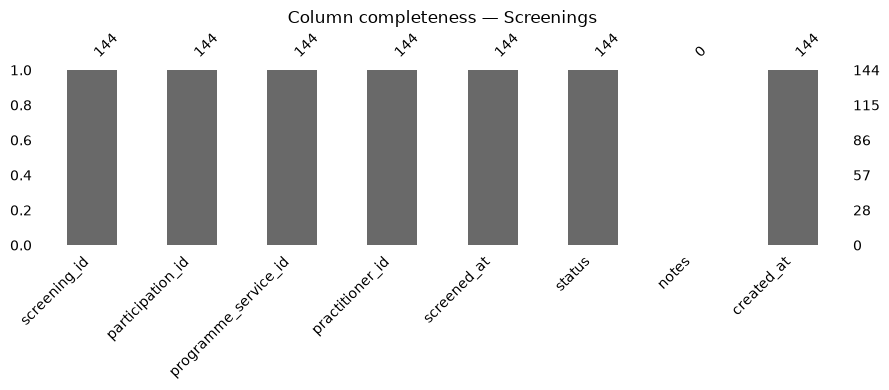

In [14]:
null_summary = pd.DataFrame({
    'null_count': scr.isnull().sum(),
    'null_pct': (scr.isnull().sum() / len(scr) * 100).round(1)
})
print(null_summary)

fig, ax = plt.subplots(figsize=(9, 4))
msno.bar(scr, ax=ax, fontsize=10)
plt.title('Column completeness — Screenings')
plt.tight_layout()
plt.savefig('screenings_missingno_bar.png', dpi=100)
plt.show()

In [15]:
assert scr['notes'].isnull().all(), "expected notes to be fully null in this extract"

required_fields = ['screening_id', 'participation_id', 'programme_service_id',
                    'practitioner_id', 'screened_at', 'status', 'created_at']
for col in required_fields:
    assert scr[col].notna().all(), f"unexpected nulls in required field: {col}"

print("notes: 100% null -> STRUCTURAL, not defect.")
print("  Consistent with the Data Analytics Handbook's instruction to")
print("  'restrict narrative notes' on clinical-adjacent workflows.")
print()
print("All 7 other fields: 0% null -> no defect nulls detected in this extract.")

notes: 100% null -> STRUCTURAL, not defect.
  Consistent with the Data Analytics Handbook's instruction to
  'restrict narrative notes' on clinical-adjacent workflows.

All 7 other fields: 0% null -> no defect nulls detected in this extract.


## 3. Panel Design
If every participation goes through the same fixed panel of services,
`144 rows / 24 participations` should equal the number of distinct services
exactly, with no omissions or repeats.

In [16]:
screenings_per_par = scr.groupby('participation_id').size()
print(screenings_per_par.value_counts())

assert screenings_per_par.nunique() == 1, "screenings-per-participation count is not uniform"
assert screenings_per_par.iloc[0] == scr['programme_service_id'].nunique(), \
    "screenings-per-participation does not equal the number of distinct services"

expected_services = tuple(sorted(scr['programme_service_id'].unique()))
service_sets = scr.groupby('participation_id')['programme_service_id'].apply(lambda s: tuple(sorted(s)))
mismatches = service_sets[service_sets != expected_services]
assert len(mismatches) == 0, f"participations with an irregular service panel: {mismatches.index.tolist()}"

print(f"\nPASS: all {len(screenings_per_par)} participations have exactly "
      f"{screenings_per_par.iloc[0]} screenings, covering the identical "
      f"{len(expected_services)}-service panel with no omissions and no repeats.")

6    24
Name: count, dtype: int64

PASS: all 24 participations have exactly 6 screenings, covering the identical 6-service panel with no omissions and no repeats.


## 4. Confirmed relationships

### 4.1 Screenings ↔ Measurements confirmed via 'screening_id'

In [17]:
scr_ids = set(scr['screening_id'])
meas_scr_ids = set(meas['screening_id'])

orphan_measurements = meas_scr_ids - scr_ids     # measurements pointing at a screening that doesn't exist
screenings_without_measurements = scr_ids - meas_scr_ids  # screenings with zero measurement rows

assert len(orphan_measurements) == 0, f"Measurements reference screening_id(s) not present in Screenings: {orphan_measurements}"
assert len(screenings_without_measurements) == 0, f"Screenings with no Measurements at all: {screenings_without_measurements}"

print(f"Distinct screening_id in Screenings:   {scr['screening_id'].nunique()}")
print(f"Distinct screening_id in Measurements: {meas['screening_id'].nunique()}")
print(f"Orphan measurements (screening_id not in Screenings): {len(orphan_measurements)}")
print(f"Screenings with zero measurements: {len(screenings_without_measurements)}")
print()
print("CONFIRMED: perfect two-way referential integrity. Every one of the 144")
print("screenings has at least one measurement, and every measurement traces")
print("back to a real screening. screening_id is a clean, validated foreign key.")

Distinct screening_id in Screenings:   144
Distinct screening_id in Measurements: 144
Orphan measurements (screening_id not in Screenings): 0
Screenings with zero measurements: 0

CONFIRMED: perfect two-way referential integrity. Every one of the 144
screenings has at least one measurement, and every measurement traces
back to a real screening. screening_id is a clean, validated foreign key.


In [18]:
# Formal join with validate = to assert cardinality explicitly (one screening -> many measurements)
joined = scr.merge(meas, on='screening_id', how='inner', validate='one_to_many')
assert len(joined) == len(meas), "row count changed after join -- referential integrity broken somewhere"
print(f"Joined Screenings + Measurements: {joined.shape[0]} rows (matches Measurements row count: {len(meas)})")
joined.head(3)

Joined Screenings + Measurements: 264 rows (matches Measurements row count: 264)


,screening_id,participation_id,programme_service_id,practitioner_id,screened_at,status,notes,created_at,measurement_id,metric_code,numeric_value,text_value,unit,validation_status,captured_at
0,SCR-0001,PAR-001,PS-001,PRA-002,2026-06-18T07:09:00Z,completed,NaN,2026-06-18T06:30:00Z,MEA-0001,systolic_bp,119.0,NaN,mmHg,valid,2026-06-18T07:09:00Z
1,SCR-0001,PAR-001,PS-001,PRA-002,2026-06-18T07:09:00Z,completed,NaN,2026-06-18T06:30:00Z,MEA-0002,diastolic_bp,73.0,NaN,mmHg,valid,2026-06-18T07:09:00Z
2,SCR-0001,PAR-001,PS-001,PRA-002,2026-06-18T07:09:00Z,completed,NaN,2026-06-18T06:30:00Z,MEA-0003,pulse_rate,64.0,NaN,bpm,valid,2026-06-18T07:09:00Z


### 4.2 WHat does each 'programme_service_id' station actually measure?

With Measurements joined in, we can directly observe what they measure, crosstab programme_service_id against metric_code.

In [19]:
ct = pd.crosstab(joined['programme_service_id'], joined['metric_code'])
print(ct)

# Every station should produce the exact same fixed panel of metrics for
# every one of the 24 participants, with zero cross-contamination between
# stations.
for ps in ct.index:
    metrics_at_station = ct.loc[ps]
    nonzero = metrics_at_station[metrics_at_station > 0]
    assert (nonzero == 24).all(), f"{ps} does not produce a uniform 24-count panel: {nonzero.to_dict()}"
    assert (metrics_at_station[metrics_at_station == 0].index.isin(ct.columns)).all()

print()
print("CONFIRMED station -> metric panel mapping (every station: 24/24 participants, no gaps):")
for ps in sorted(ct.index):
    metrics = ct.columns[ct.loc[ps] > 0].tolist()
    print(f"  {ps}: {metrics}")

metric_code           bmi  diastolic_bp  fitness_score  glucose  height  pulse_rate  recovery_heart_rate  stress_score  systolic_bp  total_cholesterol  weight
programme_service_id                                                                                                                                          
PS-001                  0            24              0        0       0          24                    0             0           24                  0       0
PS-002                 24             0              0        0      24           0                    0             0            0                  0      24
PS-003                  0             0              0       24       0           0                    0             0            0                  0       0
PS-004                  0             0              0        0       0           0                    0             0            0                 24       0
PS-005                  0             0       

### 4.3 Screenings ↔ Practitioners; CONFIRMED via `practitioner_id`

In [20]:
scr_prac_ids = set(scr['practitioner_id'])
prac_ids = set(prac['practitioner_id'])

orphan_practitioners = scr_prac_ids - prac_ids
unused_practitioners = prac_ids - scr_prac_ids

assert len(orphan_practitioners) == 0, f"Screenings reference practitioner_id(s) not in Practitioners: {orphan_practitioners}"

print(f"Distinct practitioner_id in Screenings: {len(scr_prac_ids)}")
print(f"Distinct practitioner_id in Practitioners: {len(prac_ids)}")
print(f"practitioner_id referenced in Screenings but missing from Practitioners: {orphan_practitioners}")
print(f"practitioner_id present in Practitioners but never used in Screenings: {unused_practitioners}")
print()
print("CONFIRMED: exact 1:1 match. All 3 practitioners in the reference table")
print("are used, and every practitioner_id in Screenings resolves cleanly.")
print()
prac[['practitioner_id', 'practitioner_type', 'registration_body', 'verification_status', 'active']]

Distinct practitioner_id in Screenings: 3
Distinct practitioner_id in Practitioners: 3
practitioner_id referenced in Screenings but missing from Practitioners: set()
practitioner_id present in Practitioners but never used in Screenings: set()

CONFIRMED: exact 1:1 match. All 3 practitioners in the reference table
are used, and every practitioner_id in Screenings resolves cleanly.



,practitioner_id,practitioner_type,registration_body,verification_status,active
0,PRA-001,nurse,BHPC,verified,True
1,PRA-002,nurse,BHPC,verified,True
2,PRA-003,fitness coach,other,verified,True


In [21]:
scr_prac = scr.merge(prac, on='practitioner_id', how='left', validate='many_to_one')
assert scr_prac['practitioner_type'].notna().all(), "some screenings failed to resolve a practitioner_type after join"
assert scr_prac['verification_status'].eq('verified').all(), "found a screening performed by a non-verified practitioner"
assert scr_prac['active'].all(), "found a screening performed by an inactive practitioner"

print("PASS: every screening in this extract was performed by a verified, active practitioner.")
print()
print(pd.crosstab(scr_prac['programme_service_id'], scr_prac['practitioner_type']))

PASS: every screening in this extract was performed by a verified, active practitioner.

practitioner_type     fitness coach  nurse
programme_service_id                      
PS-001                            0     24
PS-002                            0     24
PS-003                            0     24
PS-004                            0     24
PS-005                            0     24
PS-006                           24      0


## 5. Categorical distributions
status, programme_service_id, and practitioner_id.

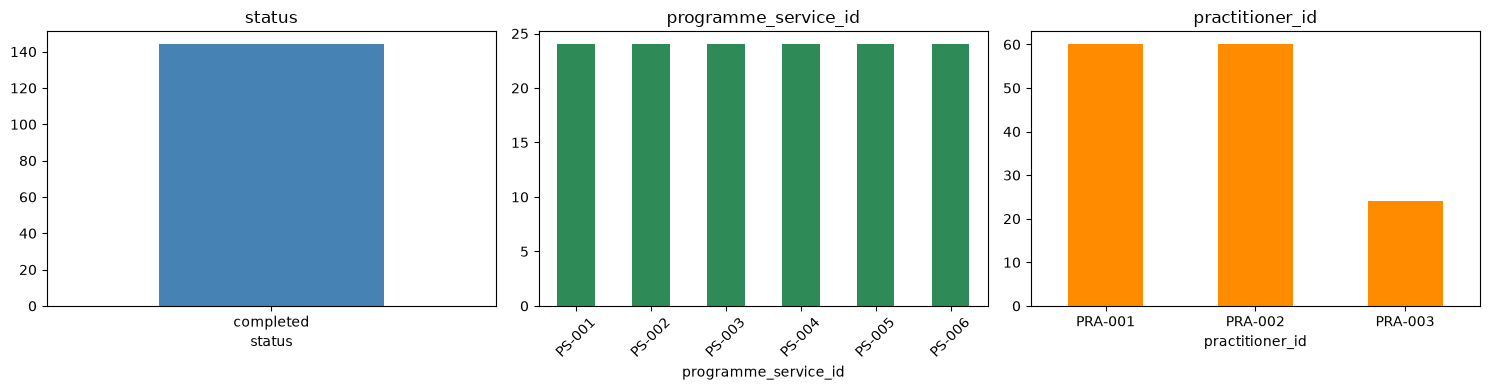

status
completed    144
Name: count, dtype: int64

programme_service_id
PS-001    24
PS-002    24
PS-003    24
PS-004    24
PS-005    24
PS-006    24
Name: count, dtype: int64

practitioner_id
PRA-001    60
PRA-002    60
PRA-003    24
Name: count, dtype: int64


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scr['status'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('status')
axes[0].tick_params(axis='x', rotation=0)

scr['programme_service_id'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('programme_service_id')
axes[1].tick_params(axis='x', rotation=45)

scr['practitioner_id'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('practitioner_id')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('screenings_categorical_distributions.png', dpi=100)
plt.show()

print(scr['status'].value_counts(dropna=False))
print()
print(scr['programme_service_id'].value_counts().sort_index())
print()
print(scr['practitioner_id'].value_counts().sort_index())

In [25]:
assert scr['status'].nunique() == 1, "expected a single status value in this extract"
assert meas['validation_status'].nunique() == 1, "expected a single validation_status value in Measurements"

print(f"Screenings.status is degenerate: 100% '{scr['status'].iloc[0]}'.")
print(f"Measurements.validation_status is also degenerate: 100% '{meas['validation_status'].iloc[0]}'.")
print()
print("Both status-like fields across both tables show zero variation in this")
print("extract. There is no incomplete, quarantined, invalid, or rejected")
print("record anywhere in this dataset to validate failure-path handling")
print("against. Any completion-rate or data-quality-rate metric built on")
print("either field is untestable against this data alone.")

Screenings.status is degenerate: 100% 'completed'.
Measurements.validation_status is also degenerate: 100% 'valid'.

Both status-like fields across both tables show zero variation in this
extract. There is no incomplete, quarantined, invalid, or rejected
record anywhere in this dataset to validate failure-path handling
against. Any completion-rate or data-quality-rate metric built on
either field is untestable against this data alone.


## 6. Practitioner ↔ service relationship

Confirmed via the join in Section 4.2/4.3. Restated here for the
categorical-distribution section's completeness.

In [26]:
ct2 = pd.crosstab(scr['programme_service_id'], scr['practitioner_id'])
print(ct2)

ps006_practitioners = scr.loc[scr['programme_service_id'] == 'PS-006', 'practitioner_id'].unique()
assert len(ps006_practitioners) == 1

generalist_services = ['PS-001', 'PS-002', 'PS-003', 'PS-004', 'PS-005']
sub = scr[scr['programme_service_id'].isin(generalist_services)]
practitioners_per_visit = sub.groupby('participation_id')['practitioner_id'].nunique()
assert (practitioners_per_visit == 1).all()

print(f"\nPASS: PS-006 (fitness_score + recovery_heart_rate) is performed exclusively "
      f"by {ps006_practitioners[0]} (practitioner_type='fitness coach') across all 24 occurrences.")
print(f"PASS: for every visit, a single nurse ({', '.join(sorted(scr[scr['programme_service_id'].isin(generalist_services)]['practitioner_id'].unique()))}) "
      f"runs the full PS-001..PS-005 clinical panel end-to-end.")
print()
print("Confirmed reading: 2 interchangeable nurses (PRA-001, PRA-002) each run")
print("the clinical panel (BP/pulse, anthropometry, glucose, cholesterol,")
print("stress) for a subset of visits; 1 fitness coach (PRA-003) runs the")
print("fitness station for every visit. This matches practitioner_type in the")
print("Practitioners table exactly -- specialization is by professional")
print("registration, not arbitrary assignment.")

practitioner_id       PRA-001  PRA-002  PRA-003
programme_service_id                           
PS-001                     12       12        0
PS-002                     12       12        0
PS-003                     12       12        0
PS-004                     12       12        0
PS-005                     12       12        0
PS-006                      0        0       24

PASS: PS-006 (fitness_score + recovery_heart_rate) is performed exclusively by PRA-003 (practitioner_type='fitness coach') across all 24 occurrences.
PASS: for every visit, a single nurse (PRA-001, PRA-002) runs the full PS-001..PS-005 clinical panel end-to-end.

Confirmed reading: 2 interchangeable nurses (PRA-001, PRA-002) each run
the clinical panel (BP/pulse, anthropometry, glucose, cholesterol,
stress) for a subset of visits; 1 fitness coach (PRA-003) runs the
fitness station for every visit. This matches practitioner_type in the
Practitioners table exactly -- specialization is by professional
registrat

## 7. Cross-field chronological validation

In [27]:
scr['screened_at'] = pd.to_datetime(scr['screened_at'])
scr['created_at'] = pd.to_datetime(scr['created_at'])

assert (scr['created_at'] <= scr['screened_at']).all(), \
    "found rows where created_at is after screened_at"
print("PASS: created_at <= screened_at holds for all rows.")

assert scr['created_at'].nunique() == 1, "expected created_at to be a single constant value in this extract"
print(f"\ncreated_at is a single constant value across all {len(scr)} rows: {scr['created_at'].iloc[0]}")
print("Reads as a batch-load / table-seed timestamp, not a genuine per-record")
print("creation event -- should not be used as a data-entry latency proxy.")

PASS: created_at <= screened_at holds for all rows.

created_at is a single constant value across all 144 rows: 2026-06-18 06:30:00+00:00
Reads as a batch-load / table-seed timestamp, not a genuine per-record
creation event -- should not be used as a data-entry latency proxy.


In [28]:
meas['captured_at'] = pd.to_datetime(meas['captured_at'])
joined_ts = scr.merge(meas, on='screening_id', how='inner')

mismatch = joined_ts[joined_ts['captured_at'] != joined_ts['screened_at']]
assert len(mismatch) == 0, f"{len(mismatch)} measurement rows have captured_at != screened_at for their screening"

print(f"PASS: captured_at in Measurements equals screened_at in Screenings for "
      f"all {len(joined_ts)} joined rows, with zero exceptions.")
print()
print("This means captured_at was derived FROM screened_at (a copy-through, one")
print("value per screening_id, fanned out to every measurement under it) rather")
print("than captured independently at measurement time. Practical consequence:")
print("Measurements CANNOT be used as an independent source to detect or")
print("correct the screened_at timestamp defect found in Section 8 below --")
print("captured_at inherits the exact same defect, row for row.")

PASS: captured_at in Measurements equals screened_at in Screenings for all 264 joined rows, with zero exceptions.

This means captured_at was derived FROM screened_at (a copy-through, one
value per screening_id, fanned out to every measurement under it) rather
than captured independently at measurement time. Practical consequence:
Measurements CANNOT be used as an independent source to detect or
correct the screened_at timestamp defect found in Section 8 below --
captured_at inherits the exact same defect, row for row.


## 8. Sequence anomaly detection

Within a single visit, the six screenings should progress forward in time as
the participant moves station to station. Sorted each participation's rows by
`programme_service_id` (the confirmed service order from Section 4.2 for
what each station actually measures) and also checking for non-increasing
`screened_at`.

In [29]:
anomalous_visits = []
for pid, grp in scr.groupby('participation_id'):
    grp = grp.sort_values('programme_service_id')
    diffs = grp['screened_at'].diff().dt.total_seconds().div(60).dropna()
    if (diffs <= 0).any():
        anomalous_visits.append(pid)

print(f"Visits with a non-increasing screened_at step somewhere in the "
      f"PS-001..PS-006 sequence: {len(anomalous_visits)} of {scr['participation_id'].nunique()}")
print(anomalous_visits)

Visits with a non-increasing screened_at step somewhere in the PS-001..PS-006 sequence: 6 of 24
['PAR-005', 'PAR-006', 'PAR-012', 'PAR-013', 'PAR-018', 'PAR-019']


In [30]:
affected = []
for pid, grp in scr.groupby('participation_id'):
    grp = grp.sort_values('programme_service_id').reset_index()
    base_time = grp.loc[0, 'screened_at']
    for i, row in grp.iterrows():
        expected = base_time + pd.Timedelta(minutes=4 * i)
        if row['screened_at'] != expected:
            affected.append({
                'participation_id': pid,
                'screening_id': row['screening_id'],
                'programme_service_id': row['programme_service_id'],
                'expected_screened_at': expected,
                'actual_screened_at': row['screened_at'],
                'diff_minutes': (row['screened_at'] - expected).total_seconds() / 60,
            })

affected_df = pd.DataFrame(affected)
print(f"Rows deviating from the clean +4-minute cadence: {len(affected_df)} of {len(scr)} "
      f"({len(affected_df)/len(scr)*100:.1f}%)")
print(f"Distinct visits affected: {affected_df['participation_id'].nunique()} of {scr['participation_id'].nunique()}")
assert set(affected_df['diff_minutes'].unique()) == {-60.0}, \
    "expected every deviation to be exactly -60 minutes"
print(f"Distinct diff_minutes values observed: {sorted(affected_df['diff_minutes'].unique())} (always exactly -60)")
affected_df

Rows deviating from the clean +4-minute cadence: 18 of 144 (12.5%)
Distinct visits affected: 6 of 24
Distinct diff_minutes values observed: [np.float64(-60.0)] (always exactly -60)


,participation_id,screening_id,programme_service_id,expected_screened_at,actual_screened_at,diff_minutes
0,PAR-005,SCR-0029,PS-005,2026-06-18 08:01:00+00:00,2026-06-18 07:01:00+00:00,-60.0
1,PAR-005,SCR-0030,PS-006,2026-06-18 08:05:00+00:00,2026-06-18 07:05:00+00:00,-60.0
2,PAR-006,SCR-0033,PS-003,2026-06-18 08:02:00+00:00,2026-06-18 07:02:00+00:00,-60.0
3,PAR-006,SCR-0034,PS-004,2026-06-18 08:06:00+00:00,2026-06-18 07:06:00+00:00,-60.0
4,PAR-006,SCR-0035,PS-005,2026-06-18 08:10:00+00:00,2026-06-18 07:10:00+00:00,-60.0
5,PAR-006,SCR-0036,PS-006,2026-06-18 08:14:00+00:00,2026-06-18 07:14:00+00:00,-60.0
6,PAR-012,SCR-0070,PS-004,2026-06-18 09:00:00+00:00,2026-06-18 08:00:00+00:00,-60.0
7,PAR-012,SCR-0071,PS-005,2026-06-18 09:04:00+00:00,2026-06-18 08:04:00+00:00,-60.0
8,PAR-012,SCR-0072,PS-006,2026-06-18 09:08:00+00:00,2026-06-18 08:08:00+00:00,-60.0
9,PAR-013,SCR-0074,PS-002,2026-06-18 09:01:00+00:00,2026-06-18 08:01:00+00:00,-60.0


In [31]:
print("ROOT CAUSE (inferred): an hour-carry bug.")
print()
example = scr[scr['participation_id'] == 'PAR-006'].sort_values('programme_service_id')[['programme_service_id', 'screened_at']]
print(example.to_string(index=False))
print()
print("Minutes were computed as (start_minute + 4*i) % 60 without carrying the")
print("overflow into the hour component. Once the hour 'sticks' at a wrap")
print("point, every later screening in that visit inherits the wrong hour --")
print("confirmed in Section 7 to propagate identically into")
print("Measurements.captured_at, since that field is a direct copy.")
print()
print("Affects 6 of 24 visits (25%), 18 of 144 screening rows (12.5%), and by")
print("extension every Measurements row under those 18 screenings.")

ROOT CAUSE (inferred): an hour-carry bug.

programme_service_id               screened_at
              PS-001 2026-06-18 07:54:00+00:00
              PS-002 2026-06-18 07:58:00+00:00
              PS-003 2026-06-18 07:02:00+00:00
              PS-004 2026-06-18 07:06:00+00:00
              PS-005 2026-06-18 07:10:00+00:00
              PS-006 2026-06-18 07:14:00+00:00

Minutes were computed as (start_minute + 4*i) % 60 without carrying the
overflow into the hour component. Once the hour 'sticks' at a wrap
point, every later screening in that visit inherits the wrong hour --
confirmed in Section 7 to propagate identically into
Measurements.captured_at, since that field is a direct copy.

Affects 6 of 24 visits (25%), 18 of 144 screening rows (12.5%), and by
extension every Measurements row under those 18 screenings.


In [32]:
naive_start = scr.groupby('participation_id')['screened_at'].min()
true_start = scr.sort_values('programme_service_id').groupby('participation_id')['screened_at'].first()
mismatch = naive_start[naive_start != true_start]
print(f"Visits where naive MIN(screened_at) does NOT equal the true first-service "
      f"(PS-001) timestamp: {len(mismatch)}")
print(pd.DataFrame({'naive_min': naive_start[mismatch.index], 'true_ps001_time': true_start[mismatch.index]}))
print()
print("CAUTION: any query doing MIN(screened_at) or MIN(captured_at) GROUP BY")
print("participation_id to find 'visit start time' will silently pick the")
print("corrupted timestamp for these 6 visits.")

Visits where naive MIN(screened_at) does NOT equal the true first-service (PS-001) timestamp: 6
                                 naive_min           true_ps001_time
participation_id                                                    
PAR-005          2026-06-18 07:01:00+00:00 2026-06-18 07:45:00+00:00
PAR-006          2026-06-18 07:02:00+00:00 2026-06-18 07:54:00+00:00
PAR-012          2026-06-18 08:00:00+00:00 2026-06-18 08:48:00+00:00
PAR-013          2026-06-18 08:01:00+00:00 2026-06-18 08:57:00+00:00
PAR-018          2026-06-18 09:02:00+00:00 2026-06-18 09:42:00+00:00
PAR-019          2026-06-18 09:03:00+00:00 2026-06-18 09:51:00+00:00

CAUTION: any query doing MIN(screened_at) or MIN(captured_at) GROUP BY
participation_id to find 'visit start time' will silently pick the
corrupted timestamp for these 6 visits.


## 9. Duplicate screening detection

Two levels: exact full-row duplicates, and logical duplicates on the natural
composite key (`participation_id`, `programme_service_id`).

In [34]:
exact_dupes = scr.duplicated().sum()
print(f"Exact full-row duplicates: {exact_dupes}")
assert exact_dupes == 0, "found exact duplicate rows"

composite_dupes = scr.duplicated(subset=['participation_id', 'programme_service_id'], keep=False)
print(f"Duplicate (participation_id, programme_service_id) pairs: {composite_dupes.sum()}")
assert composite_dupes.sum() == 0, "found duplicate participation+service screenings not expected in this extract"

meas_dupes = meas.duplicated().sum()
print(f"Exact full-row duplicates in Measurements: {meas_dupes}")
assert meas_dupes == 0

meas_composite_dupes = meas.duplicated(subset=['screening_id', 'metric_code'], keep=False)
print(f"Duplicate (screening_id, metric_code) pairs in Measurements: {meas_composite_dupes.sum()}")
assert meas_composite_dupes.sum() == 0, "found duplicate metric captures for the same screening"

print()
print("PASS: no duplicates at any grain in either table, both composite keys")
print("(participation_id, programme_service_id) on Screenings and")
print("(screening_id, metric_code) on Measurements are clean.")

Exact full-row duplicates: 0
Duplicate (participation_id, programme_service_id) pairs: 0
Exact full-row duplicates in Measurements: 0
Duplicate (screening_id, metric_code) pairs in Measurements: 0

PASS: no duplicates at any grain in either table, both composite keys
(participation_id, programme_service_id) on Screenings and
(screening_id, metric_code) on Measurements are clean.


## 10. Cross-check against prior EDA flags

The Participations EDA flagged `PAR-017` as a likely manual entry error.
This is to check whether that anomaly propagates into Screenings or Measurements.

In [36]:
par017 = scr[scr['participation_id'] == 'PAR-017'].sort_values('programme_service_id')
print(par017[['screening_id', 'programme_service_id', 'practitioner_id', 'screened_at', 'status']].to_string(index=False))
print()

is_anomalous_here = 'PAR-017' in affected_df['participation_id'].values
print(f"PAR-017 shows the hour-rollover defect in Screenings: {is_anomalous_here}")

par017_meas = meas[meas['screening_id'].isin(par017['screening_id'])]
print(f"\nPAR-017 measurement count: {len(par017_meas)} (expected 11)")
assert len(par017_meas) == 11, "PAR-017 has an incomplete measurement set"
print("PAR-017's measurements are complete and unremarkable.")
print()
print("PAR-017's records in both Screenings and Measurements are entirely")
print("clean. The anomaly flagged against PAR-017 in the Participations table")
print("does not manifest in either downstream table. Consistent with the")
print("prior notebook's conclusion that the two issues have independent causes.")

screening_id programme_service_id practitioner_id               screened_at    status
    SCR-0097               PS-001         PRA-002 2026-06-18 09:33:00+00:00 completed
    SCR-0098               PS-002         PRA-002 2026-06-18 09:37:00+00:00 completed
    SCR-0099               PS-003         PRA-002 2026-06-18 09:41:00+00:00 completed
    SCR-0100               PS-004         PRA-002 2026-06-18 09:45:00+00:00 completed
    SCR-0101               PS-005         PRA-002 2026-06-18 09:49:00+00:00 completed
    SCR-0102               PS-006         PRA-003 2026-06-18 09:53:00+00:00 completed

PAR-017 shows the hour-rollover defect in Screenings: False

PAR-017 measurement count: 11 (expected 11)
PAR-017's measurements are complete and unremarkable.

PAR-017's records in both Screenings and Measurements are entirely
clean. The anomaly flagged against PAR-017 in the Participations table
does not manifest in either downstream table. Consistent with the
prior notebook's conclusion that 